# 03 - Ajuste espectral

Demostracion del ajuste iterativo. El modo por defecto ajusta amplitudes en frecuencia preservando fase y corrige baseline en cada iteracion; las wavelets gaussianas-coseno quedan disponibles como modo alternativo.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from signalprocessor.io import read_motion, read_target_spectrum
from signalprocessor.matching import MatchingConfig, match_spectrum
from signalprocessor.scaling import linear_scale
from signalprocessor.spectra import response_spectrum


In [2]:
seed = read_motion(ROOT / 'examples/data/benchmark/unscaled_motion/ATICOEW.csv')
target = read_target_spectrum(ROOT / 'examples/data/response_spectrum/EPU_475.csv')

linear = linear_scale(seed, target, t_min=0.2, t_max=2.0)
matched = match_spectrum(seed, target, MatchingConfig(max_iterations=15, relaxation=0.35, t_min=0.2, t_max=2.0))
pd.DataFrame(matched.history)


,iteration,max_abs_log_error,rms_log_error
0,0.0,0.915798,0.517697
1,1.0,0.689239,0.383349
2,2.0,0.552650,0.281430
3,3.0,0.418983,0.203947
4,4.0,0.317967,0.149363
5,5.0,0.244589,0.111406
6,6.0,0.190744,0.084802
7,7.0,0.150808,0.065946
8,8.0,0.120849,0.052371
9,9.0,0.098100,0.042415


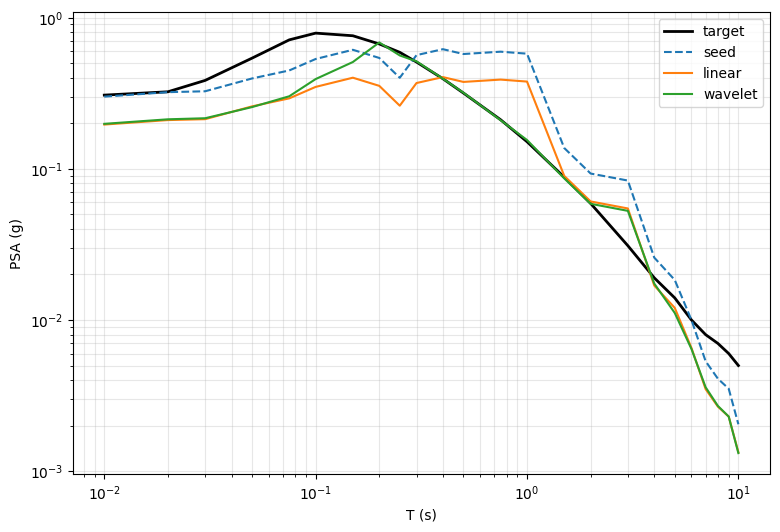

In [3]:
seed_spec = response_spectrum(seed, target.periods)

plt.figure(figsize=(9, 6))
plt.loglog(target.periods, target.sa, 'k-', lw=2.0, label='target')
plt.loglog(seed_spec.periods, seed_spec.sa, '--', label='seed')
plt.loglog(linear.scaled_spectrum.periods, linear.scaled_spectrum.sa, label='linear')
plt.loglog(matched.spectrum.periods, matched.spectrum.sa, label='wavelet')
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend();


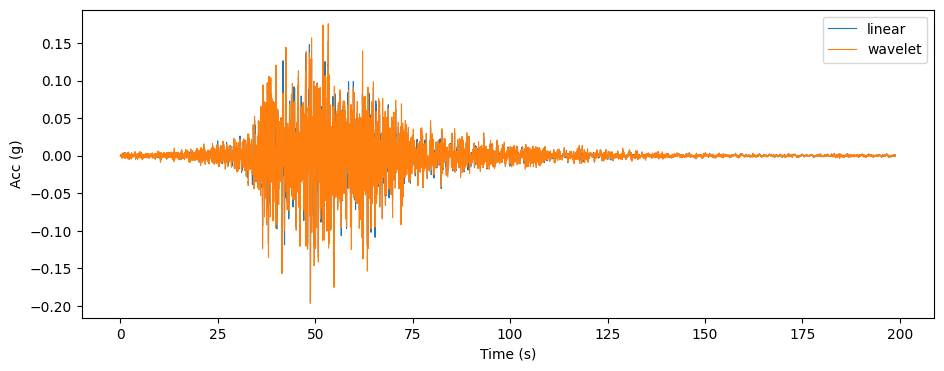

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(linear.record.time, linear.record.as_units('g').acceleration, lw=0.8, label='linear')
plt.plot(matched.record.time, matched.record.as_units('g').acceleration, lw=0.8, label='wavelet')
plt.xlabel('Time (s)')
plt.ylabel('Acc (g)')
plt.legend();
